# Boundary Generation — Semifreddo + Ledidi (single example)

Optimises the central bin (index 256 in the 512-bin map, index 320 counting the
64-bin cropping offset) of a flat genomic region to produce a strong boundary.

**Key difference from full-sequence optimisation:** only the 11-bin padded sequence
slice around the edited bin is passed through the convolutional tower on each step;
all other activations are served from the pre-cached tower output.

```
center bin (in map) : 256
center bin (in 640) : 256 + 64 (cropping) = 320
sequence window     : bin 315–325 → (320-5)*2048 to (320+6)*2048 = 11 bins = 22 528 bp
bins replaced       : 318–322 (central 5)
```


## 1. Imports

In [1]:
import os
import sys

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

sys.path.append(os.path.abspath("/home1/smaruj/pytorch_akita/"))
sys.path.insert(0, "/home1/smaruj/ledidi/ledidi/")
sys.path.insert(0, os.path.abspath("/home1/smaruj/ledidi_akita/"))

from akita.model import SeqNN
from ledidi import Ledidi
from semifreddo.semifreddo import SemifreddoLedidiWrapper
from utils.data_utils import from_upper_triu
from utils.losses_utils import LocalL1Loss

## 2. Parameters

In [2]:
# ── Sequence to optimise ─────────────────────────────────────────────────
FOLD  = 0
CHROM = "chr3"
START = 38438912
END   = 39749632
STEM  = f"{CHROM}_{START}_{END}"

SEQ_BASE_DIR   = "/project2/fudenber_735/smaruj/sequence_design/ledidi_semifreddo_akita/analysis/flat_regions"
TARGET_DIR = "/project2/fudenber_735/smaruj/sequence_design/ledidi_semifreddo_akita/optimizations/boundaries"
MASK_DIR     = "/project2/fudenber_735/smaruj/sequence_design/ledidi_semifreddo_akita/optimizations/feature_masks"
MODEL_PATH = ("/home1/smaruj/pytorch_akita/models/finetuned/mouse/Hsieh2019_mESC/checkpoints/"
              "Akita_v2_mouse_Hsieh2019_mESC_model0_finetuned.pth")

SEQ_PATH    = f"{SEQ_BASE_DIR}/mouse_sequences/fold{FOLD}/{STEM}_X.pt"
TOWER_PATH  = f"{SEQ_BASE_DIR}/mouse_tower_outputs/fold{FOLD}/{STEM}_tower_out.pt"
TARGET_PATH = f"{TARGET_DIR}/targets/boundary_neg0p5/fold{FOLD}/{STEM}_target.pt"
MASK_PATH = f"{MASK_DIR}/boundary_mask.pt"

# ── Semifreddo bin coordinates ────────────────────────────────────────────
# Central bin in the 512-bin contact map
CENTER_BIN_MAP = 256
# Same bin in the 640-bin tower output (add the 64-bin Akita cropping offset)
CENTER_BIN_640 = CENTER_BIN_MAP + 64   # = 320
CONTEXT_BINS   = 5   # ±5 bins → 11-bin window → Pearson R = 1.0 vs full model
BIN_SIZE       = 2048  # bp per bin

# ── Optimisation hyperparameters ─────────────────────────────────────────
L                  = 125.0   # input-loss regularisation weight
MAX_ITER           = 2000
EARLY_STOPPING     = 2000

# ── Visualisation ────────────────────────────────────────────────────────
VMIN, VMAX = -0.6, 0.6
CMAP       = 'RdBu_r'

## 3. Load Model

In [3]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

model = SeqNN()
model.load_state_dict(torch.load(MODEL_PATH, map_location=device, weights_only=True))
model.to(device).eval()
print("Model loaded")

Device: cuda:0
Model loaded


## 4. Load Pre-generated Files

In [4]:
X      = torch.load(SEQ_PATH,    weights_only=True).to(device)               # (1, 4, L)
tower  = torch.load(TOWER_PATH,  weights_only=True).to(device)               # (1, 128, 640)
target = torch.load(TARGET_PATH, weights_only=True).to(device)               # (1, 1, N_triu)

print(f"X shape      : {X.shape}")
print(f"Tower shape  : {tower.shape}")
print(f"Target shape : {target.shape}")

X shape      : torch.Size([1, 4, 1310720])
Tower shape  : torch.Size([1, 128, 640])
Target shape : torch.Size([1, 1, 130305])


## 5. Build SemifreddoLedidiWrapper

The wrapper extracts the 11-bin padded sequence slice from `X` on every Ledidi step
and runs only that slice through the convolutional tower, splicing the result back
into the cached `tower` activations.

In [5]:
sf_wrapper = SemifreddoLedidiWrapper(
    model                   = model,
    precomputed_full_output = tower,
    full_X                  = X,
    edited_bin              = CENTER_BIN_MAP,   # 256, NOT 320
    context_bins            = CONTEXT_BINS,
    cropping_applied        = 64,
)

print(f"Sequence slice : bp {sf_wrapper.seq_slice_start:,} – {sf_wrapper.seq_slice_end:,}")
print(f"Center bin bp  : {sf_wrapper.center_bp_start:,} – {sf_wrapper.center_bp_end:,}")

# Sanity check — pass only the central bin
X_center = X[:, :, sf_wrapper.center_bp_start:sf_wrapper.center_bp_end]  # (1, 4, 2048)

with torch.no_grad():
    y_full = model(X)
    y_sf   = sf_wrapper(X_center)

r, _ = pearsonr(y_full.cpu().flatten().numpy(), y_sf.cpu().flatten().numpy())
print(f"\nSanity check — Pearson R (full vs Semifreddo): {r:.6f}  (expect 1.0)")

Sequence slice : bp 645,120 – 667,648
Center bin bp  : 655,360 – 657,408

Sanity check — Pearson R (full vs Semifreddo): 1.000000  (expect 1.0)


/home1/smaruj/miniconda3/envs/pytorch_hic/lib/python3.10/site-packages/torch/nn/modules/conv.py:306: UserWarning: Applied workaround for CuDNN issue, install nvrtc.so (Triggered internally at ../aten/src/ATen/native/cudnn/Conv_v8.cpp:84.)
  return F.conv1d(input, weight, bias, self.stride,


## 6. Run Ledidi Optimisation

Ledidi receives `SemifreddoLedidiWrapper` as its model.
On every step it calls `sf_wrapper(X_hat)`, which:
1. Slices `X_hat[:, :, seq_slice_start:seq_slice_end]` — the 11-bin window
2. Passes only that 22 528 bp slice through `conv_block_1 → conv_tower`
3. Splices the 5 central recomputed bins into the cached tower activations
4. Runs the full trunk to produce the contact map prediction

In [6]:
# Load mask
boundary_mask = torch.load(MASK_PATH, weights_only=True).to(device)

local_output_loss = LocalL1Loss(boundary_mask, n_triu=130305, reduction='sum').to(device)

In [7]:
ledidi_optimizer = Ledidi(
    sf_wrapper,
    shape              = X_center.shape[1:],          # (4, 2048)
    input_loss         = torch.nn.L1Loss(reduction='sum'),
    output_loss        = local_output_loss,
    batch_size         = 1,
    l                  = L,
    max_iter           = MAX_ITER,
    early_stopping_iter = EARLY_STOPPING,
    return_history     = True,
    verbose            = True,
).cuda()

generated_seq, history = ledidi_optimizer.fit_transform(X_center, target)

iter=I	input_loss=0.0	output_loss=5.134e+04	total_loss=5.134e+04	time=0.0
iter=100	input_loss=78.0	output_loss=3.098e+04	total_loss=4.073e+04	time=7.42
iter=200	input_loss=100.0	output_loss=2.671e+04	total_loss=3.921e+04	time=7.327
iter=300	input_loss=91.0	output_loss=2.457e+04	total_loss=3.595e+04	time=7.33
iter=400	input_loss=74.0	output_loss=2.487e+04	total_loss=3.412e+04	time=7.33
iter=500	input_loss=73.0	output_loss=2.505e+04	total_loss=3.417e+04	time=7.328
iter=600	input_loss=78.0	output_loss=2.456e+04	total_loss=3.431e+04	time=7.332
iter=700	input_loss=72.0	output_loss=2.468e+04	total_loss=3.368e+04	time=7.332
iter=800	input_loss=70.0	output_loss=2.489e+04	total_loss=3.364e+04	time=7.334
iter=900	input_loss=75.0	output_loss=2.457e+04	total_loss=3.394e+04	time=7.334
iter=1000	input_loss=72.0	output_loss=2.462e+04	total_loss=3.362e+04	time=7.336
iter=1100	input_loss=74.0	output_loss=2.434e+04	total_loss=3.359e+04	time=7.335
iter=1200	input_loss=77.0	output_loss=2.427e+04	total_los

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

In [9]:
# ── Parse edit history ────────────────────────────────────────────────────────

def parse_edit_positions(edit_entry):
    """Return the set of edited positions from one history entry (3-tuple of tensors)."""
    pos_tensor = edit_entry[2]  # third element: positions within 2048 bp
    if pos_tensor.numel() == 0:
        return set()
    return set(pos_tensor.cpu().numpy().tolist())

def build_edit_events(history_edits):
    """
    Walk through accepted-edit snapshots and label each position at each step as:
      - 'new'      : newly accepted at this step
      - 'retained' : accepted in a prior step, still present
      - (absent)   : not edited at this step
    
    Returns
    -------
    steps         : list of step indices (one per accepted snapshot)
    new_pos       : list of arrays — newly accepted positions at each step
    retained_pos  : list of arrays — previously accepted positions still present
    """
    steps, new_pos, retained_pos = [], [], []
    prev_positions = set()

    for i, entry in enumerate(history_edits):
        curr_positions = parse_edit_positions(entry)
        newly_accepted  = sorted(curr_positions - prev_positions)
        still_retained  = sorted(curr_positions & prev_positions)

        steps.append(i)
        new_pos.append(np.array(newly_accepted,  dtype=int))
        retained_pos.append(np.array(still_retained, dtype=int))

        prev_positions = curr_positions

    return steps, new_pos, retained_pos

In [10]:
steps, new_pos, retained_pos = build_edit_events(history["edits"])
n_steps = len(steps)

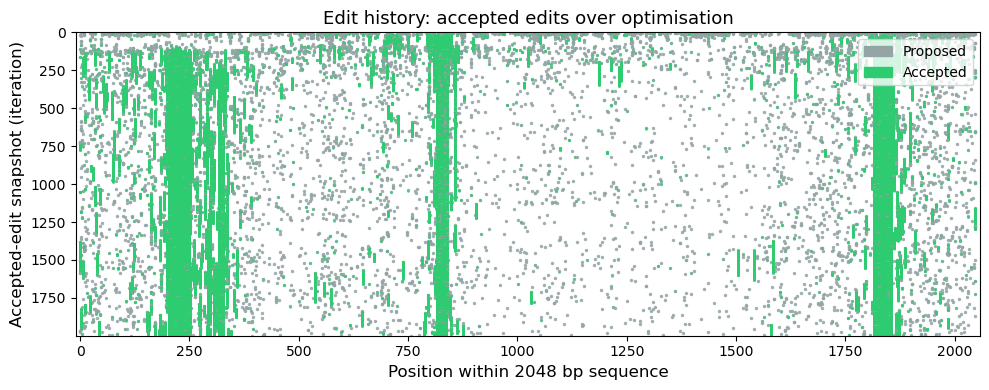

In [11]:
# ── Plot ──────────────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(10, 4))

COLOR_PROP      = "#95a5a6"   # grey - proposed edits
COLOR_ACC = "#2ecc71"   # green   — accepted edits

for step_idx, (new, ret) in enumerate(zip(new_pos, retained_pos)):
    y = step_idx
    if ret.size:
        ax.scatter(ret,  np.full(ret.size,  y), color=COLOR_ACC,
                   s=4, linewidths=0, alpha=0.6, rasterized=True)
    if new.size:
        ax.scatter(new,  np.full(new.size,  y), color=COLOR_PROP,
                   s=6, linewidths=0, alpha=0.9, rasterized=True)

# ── Axes & labels ─────────────────────────────────────────────────────────────
ax.set_xlabel("Position within 2048 bp sequence", fontsize=12)
ax.set_ylabel("Accepted-edit snapshot (iteration)", fontsize=12)
ax.set_title("Edit history: accepted edits over optimisation", fontsize=13)
ax.set_xlim(-10, 2058)
ax.set_ylim(-0.5, n_steps - 0.5)
ax.invert_yaxis()   # step 0 at top → time flows downward

legend_handles = [
    mpatches.Patch(color=COLOR_PROP,      label="Proposed"),
    mpatches.Patch(color=COLOR_ACC, label="Accepted"),
]
ax.legend(handles=legend_handles, loc="upper right", fontsize=10)

plt.tight_layout()
# plt.savefig("edit_history.png", dpi=150, bbox_inches="tight")
plt.show()

In [12]:
from memelite import fimo

In [13]:
from utils.fimo_utils import read_meme_pwm, ctcf_hits_per_seq

In [14]:
PWM_PATH = "/home1/smaruj/ledidi_akita/data/pwm/MA0139.1.meme"

In [15]:
pwm     = read_meme_pwm(PWM_PATH)
motifs  = {"CTCF": pwm}

In [16]:
edited_hits = fimo(motifs=motifs, sequences=generated_seq.cpu().detach().numpy(),
                               threshold=1e-4, reverse_complement=True)[0]

In [ ]:
edited_hits

In [17]:
from matplotlib.patches import FancyArrow
from matplotlib.gridspec import GridSpec

CTCF rows to draw: 4
   start   end strand
0    305   324      +
1   1827  1846      +
2    216   235      -
3    823   842      -


/tmp/SLURM_2865422/ipykernel_207256/3936780549.py:85: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


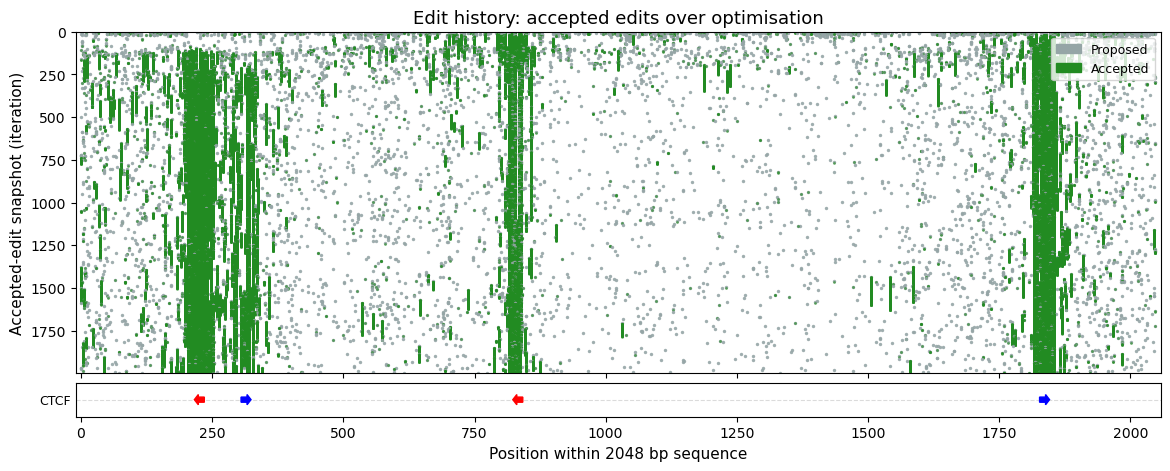

In [20]:
# ── Layout: main scatter + CTCF strip ────────────────────────────────────────
CTCF_PANEL_H = 1   # inches — fixed height for CTCF strip
main_h       = max(4, n_steps * 0.25)

fig = plt.figure(figsize=(14, 5))
gs  = GridSpec(
    2, 1,
    height_ratios=[main_h, 50],   # CTCF strip is ~3 "units" tall
    hspace=0.05,
    figure=fig,
)
ax_main = fig.add_subplot(gs[0])
ax_ctcf = fig.add_subplot(gs[1], sharex=ax_main)

# ── Main scatter ──────────────────────────────────────────────────────────────
COLOR_PROP      = "#95a5a6"   # grey - proposed edits
COLOR_ACC = "forestgreen"   # green   — accepted edits

for step_idx, (new, ret) in enumerate(zip(new_pos, retained_pos)):
    y = step_idx
    if ret.size:
        ax_main.scatter(ret, np.full(ret.size, y), color=COLOR_ACC,
                        s=4, linewidths=0, alpha=0.6, rasterized=True)
    if new.size:
        ax_main.scatter(new, np.full(new.size, y), color=COLOR_PROP,
                        s=6, linewidths=0, alpha=0.9, rasterized=True)

ax_main.set_ylabel("Accepted-edit snapshot (iteration)", fontsize=11)
ax_main.set_title("Edit history: accepted edits over optimisation", fontsize=13)
ax_main.set_xlim(-10, 2058)
ax_main.set_ylim(-0.5, n_steps - 0.5)
ax_main.invert_yaxis()
ax_main.tick_params(labelbottom=False)

legend_handles = [
    mpatches.Patch(color=COLOR_PROP,      label="Proposed"),
    mpatches.Patch(color=COLOR_ACC, label="Accepted"),
]
ax_main.legend(handles=legend_handles, loc="upper right", fontsize=9)

# ── CTCF strip ────────────────────────────────────────────────────────────────
COLOR_POS = "blue"
COLOR_NEG = "red"
Y_ARROW   = 0.5   # single row; arrows centred at y=0.5

print(f"CTCF rows to draw: {len(edited_hits)}")
print(edited_hits[["start", "end", "strand"]].to_string())

ax_ctcf.axhline(Y_ARROW, color="lightgrey", linewidth=0.8, linestyle="--", alpha=0.8)

for _, row in edited_hits.iterrows():
    start  = int(row["start"])
    end    = int(row["end"])
    strand = row["strand"]
    color  = COLOR_POS if strand == "+" else COLOR_NEG
    width  = end - start
    dx     = width if strand == "+" else -width

    arrow = FancyArrow(
        start if strand == "+" else end,
        Y_ARROW,
        dx, 0,
        width=0.15,
        head_width=0.30,
        head_length=min(25, abs(width) * 0.4),
        length_includes_head=True,
        color=color,
        zorder=3,
    )
    ax_ctcf.add_patch(arrow)

ax_ctcf.set_xlim(-10, 2058)
ax_ctcf.set_ylim(0, 1)
ax_ctcf.set_yticks([Y_ARROW])
ax_ctcf.set_yticklabels(["CTCF"], fontsize=9)
ax_ctcf.set_xlabel("Position within 2048 bp sequence", fontsize=11)
ax_ctcf.tick_params(axis="y", length=0)

# ctcf_legend = [
#     mpatches.Patch(color=COLOR_POS, label="CTCF  +  strand"),
#     mpatches.Patch(color=COLOR_NEG, label="CTCF  −  strand"),
# ]
# ax_ctcf.legend(handles=ctcf_legend, loc="upper right", fontsize=9)

plt.tight_layout()
plt.savefig("./../plots/edit_history_ctcf.svg", format="svg")
plt.show()#

In [ ]:
# Then reconstruct full sequence afterward
full_generated_seq = X.clone()
full_generated_seq[:, :, sf_wrapper.center_bp_start:sf_wrapper.center_bp_end] = generated_seq

## 7. Loss Curves

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3))

axes[0].plot(history['input_loss'],  c='0.7')
axes[0].set_title('Input Loss')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Loss')
axes[0].grid(True, linestyle='--')

axes[1].plot(history['output_loss'], c='0.3')
axes[1].set_title('Output Loss')
axes[1].set_xlabel('Iteration')
axes[1].grid(True, linestyle='--')

sns.despine()
plt.tight_layout()
plt.show()

## 8. Number of Edits

In [ ]:
n_edits = (torch.argmax(full_generated_seq, dim=1) != torch.argmax(X, dim=1)).sum().item()
print(f"Number of edited nucleotides: {n_edits:,}")

## 9. Predicted Contact Maps

In [ ]:
model.eval()
with torch.no_grad():
    pred_optimised = model(full_generated_seq)
    pred_initial   = model(X)

r_opt, _ = pearsonr(
    pred_optimised.cpu().flatten().numpy(),
    target.cpu().flatten().numpy(),
)
r_init, _ = pearsonr(
    pred_initial.cpu().flatten().numpy(),
    target.cpu().flatten().numpy(),
)
print(f"Pearson R (optimised vs target) : {r_opt:.4f}")
print(f"Pearson R (initial   vs target) : {r_init:.4f}")

## 10. Contact Map Visualisation

In [ ]:
mat_initial   = from_upper_triu(pred_initial[0, 0, :],   matrix_len=512, num_diags=2)
mat_optimised = from_upper_triu(pred_optimised[0, 0, :],  matrix_len=512, num_diags=2)
mat_target    = from_upper_triu(target[0, 0, :],          matrix_len=512, num_diags=2)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
titles = ['Initial', 'Target', 'Optimised']
matrices = [mat_initial, mat_target, mat_optimised]

for ax, mat, title in zip(axes, matrices, titles):
    im = ax.matshow(mat.astype(np.float32), cmap=CMAP, vmin=VMIN, vmax=VMAX)
    ax.set_title(title, pad=12)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle(f"{CHROM}:{START}-{END}  |  boundary strength = -0.5", y=1.02)
plt.tight_layout()
# plt.savefig(f"./../plots/boundary_sf_{STEM}.svg", format='svg', bbox_inches='tight')
plt.show()